## Teledyne FLIR Boson+
This notebook utilizes and expands on the functions and equations given by the "PythonSimulation.ipynb" notebook to determine the validity of the Teledyne FLIR Boson+ Bolometer for the SeeSat e.V. ERWIN mission.

## Spectral Radiance / Planck's Law
$$ S(\lambda, T) = \frac{2 h c^2}{\lambda^5} \cdot \frac{1}{\exp\left(\tfrac{h c}{\lambda k T}\right) - 1} $$

- $S(\lambda, T)$: Spectral Radiance
- $h$: Planck constant,
- $c$: speed of light,
- $k$: Boltzmann constant,
- $T$: temperature (K),
- $\lambda$: wavelength (m)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k, pi

def planck_lambda(lmbd, T):
    """
    Planck's law: spectral radiance per wavelength [W / (m^3 sr)]
    lmbd: wavelength in m
    T: temperature in K
    
    Uses np.expm1 for better numerical stability without clipping.
    """
    x = (h * c) / (lmbd * k * T)
    return (2 * h * c**2 / lmbd**5) / np.expm1(x)

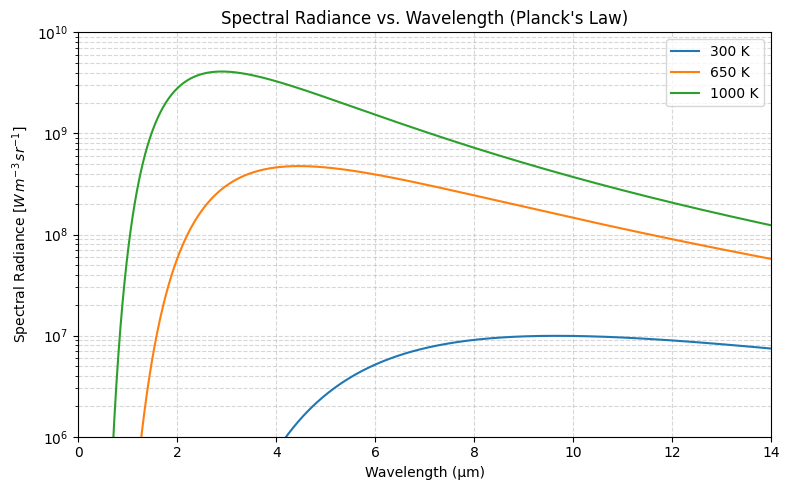

In [2]:
# Wavelengths from 0.1 to 14 micrometers, avoid zero to prevent division by zero, in meters
wavelength_um = np.linspace(0.1, 14, 1000)
wavelength_m = wavelength_um * 1e-6

temperatures = [300, 650, 1000]
labels = ["300 K", "650 K", "1000 K"]

plt.figure(figsize=(8, 5))
for T, label in zip(temperatures, labels):
    radiance = planck_lambda(wavelength_m, T)
    plt.plot(wavelength_um, radiance, label=label)

plt.xlabel("Wavelength (μm)")
plt.ylabel(r"Spectral Radiance $[W\,m^{-3}\,sr^{-1}]$")
plt.title("Spectral Radiance vs. Wavelength (Planck's Law)")
plt.yscale('log')
plt.ylim(1e6, 1e10)
plt.legend()
plt.xlim(0, 14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.show()

## Atmospheric Transmission / MODTRAN simulation
Using MODTRAN, the atmospheric transmission for a range of wavelengths can be determined

In [3]:
import pandas as pd

def get_modtran_data(file_path):
    """
    Load MODTRAN simulation data from a CSV file.
    
    Parameters:
    - file_path: Path to the CSV file containing MODTRAN data.
    
    Returns:
    - DataFrame with columns 'Wavelength' and 'Transmission'.
    """
    df = pd.read_csv(file_path, header=4)
    df.set_index('Freq', inplace=True)
    df = df.iloc[1:-1]
    df.index = 1e-2 / df.index.astype(float)
    df.index.name = 'Wavelength [m]'
    df.columns = df.columns.str.strip()
    df['combin'] = pd.to_numeric(df['combin'], errors='coerce')
    tau = df['combin'].values
    wavelength = df.index.values
    sort_idx = np.argsort(wavelength)
    wavelength = wavelength[sort_idx]
    tau = tau[sort_idx]
    return wavelength, tau, df

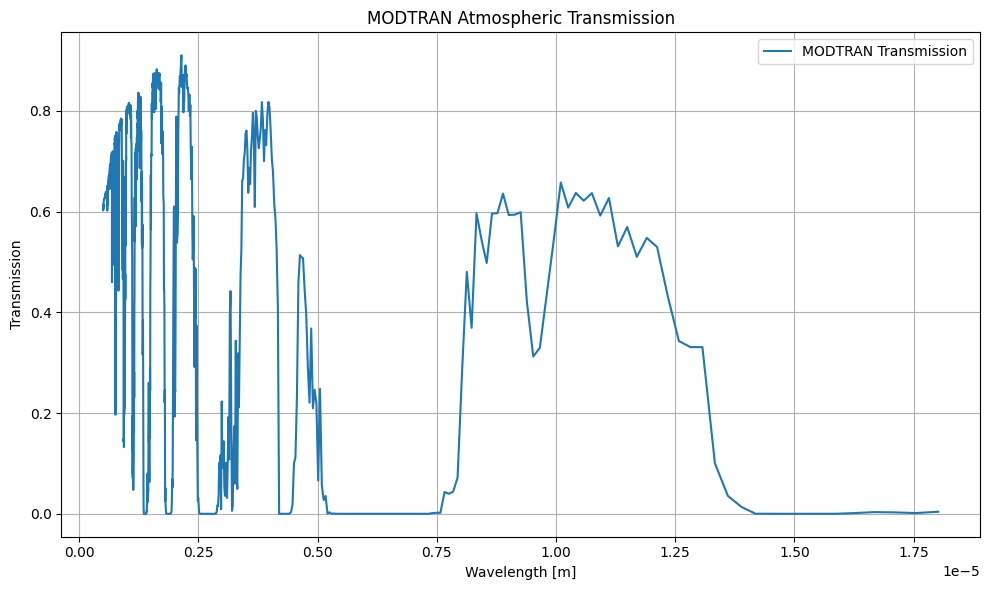

In [4]:
wavelength, transmittance, _ =  get_modtran_data('./AngstromLaw2.csv')
wavelength = wavelength
plt.figure(figsize=(10, 6))
plt.plot(wavelength, transmittance, label='MODTRAN Transmission', color='tab:blue')
plt.xlabel('Wavelength [m]')
plt.ylabel('Transmission')
plt.title('MODTRAN Atmospheric Transmission')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Imager Specification
**Teledyne FLIR Boson+**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Wavelength-Range** | 8–14 µm                | LWIR-Spectral-Range               |
| **NETD**             | 40 mK, 50 mK, 60 mK     | Detector-Noise, depends on the imager variant|
| **HFOV**              | 34° | Field of View; Only for Testing         |
| **Pixel Pitch**      | 12 µm                   | Detector-Pixel-Size                |
| **Optical Transmission** | τ<sub>opt</sub> = 0.9 | Transmission of the Optic             |
| **Pixel Count** | 320x256 / 640x512 | Number of Pixels in the matrix             |
| **IFOV (mrad)** | 1.9047619047619 | Instantaneous FoV; What a single pixel sees|

**Mission Environment (Different Optic)**

When two numbers - Pixel count: left for 320x256 / right for 640x512 
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **HFOV**      | 6° / 12° | Field of View; depends on the used Optic and Pixel Count|
| **GSD**       | 197m | Ground Sampling Distance for a single Pixel|
| **Swath width**       | 62889m / 126125m | How much the whole imager sees on the ground|

**Simulation Parameters**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Distance**       | 600km | Common orbit for CubeSats|
| **GSD**       | 197m | Ground Sampling Distance; Ground resolution|
| **Normal soil temperature**       | 300K | standard Industry estimation |
| **Fire temperature**       | 1000K | standard Industry estimation |
| **Optical Transmission**       | 0.9 (0.5) | estimation (for a 5 lens design) |
| **Detector-Efficiency**       | 0.8 | estimation |


In [5]:
theta_ap = np.deg2rad(6)  # Field of view 12° / 2 to rad

tau_op = 0.9    # optical Transmission
alpha_det = 0.8 # detector efficiency

T_fire = 1000
T_ground = 300

gsd = 197
area = 197**2

condition = (wavelength >= 8e-6) & (wavelength <= 14e-6)
band_edges = wavelength[condition]
tau_atm = transmittance[condition]

## Power Formula
Assuming Lambertian Emission and the detector being at nadir:
$$
P_\mathrm{ow} = A_\mathrm{ground}  \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap})
$$

$$
P_\mathrm{tw} = A_\mathrm{ground}  \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap})
$$

**Generic Band Power Equation**:
$$
P_\mathrm{ow} = a \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]
$$

$$
P_\mathrm{tw} = a \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]
$$

In [6]:
def integrate_band(T, lmbd_min, lmbd_max, n_samples=200):
    """
    Integrates Planck radiance over [lmbd_min, lmbd_max].
    Returns [W / (m^2 sr)].
    """
    wavelengths = np.linspace(lmbd_min, lmbd_max, n_samples)
    spectral = planck_lambda(wavelengths, T)
    return np.trapezoid(spectral, wavelengths)

def generic_band_power(band_edges, tau_atm_band, T_surface, fixed_factors, other_factors, two_way,  n_samples):
    powers = []
    for i in range(len(band_edges)-1):
        # integrate a band
        l0,l1 = band_edges[i], band_edges[i+1];
        I_band = integrate_band(T_surface, l0, l1, n_samples);
        # atmospheric transmission
        if two_way:
            I_band = I_band * (tau_atm_band[i]**2);
        else:
            I_band = I_band * tau_atm_band[i];
        # constant prefactor
        P_band = I_band * fixed_factors * other_factors;
        powers.append(P_band);

    powers = np.array(powers)
    return powers, powers.sum()

## Band Power for Ground Emission
**Mixed Pixels:**
$$P_{mix,Band} = (1 - \delta_{fire}) \cdot P_{ground,Band} + \delta_{fire} \cdot P_{fire,Band} $$

**Ground Emission:**
$$
P_\mathrm{surface} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \epsilon_{ground} \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap}) 
$$

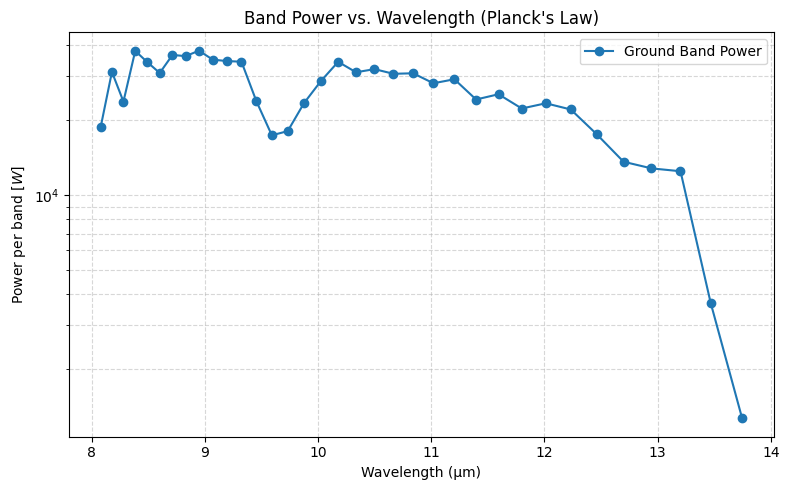

In [7]:
fixed_factors = alpha_det * area * pi * np.sin(theta_ap)**2 * tau_op
other_factors = 1
n_samples = 400

ground_powers, _ = generic_band_power(band_edges, tau_atm, T_fire, 
                                      fixed_factors, other_factors, False, n_samples)

# band_edges has length N+1 while ground_powers has length N -> use band centers for x
band_centers_um = 0.5 * (band_edges[:-1] + band_edges[1:]) * 1e6

plt.figure(figsize=(8, 5))
plt.plot(band_centers_um, ground_powers, marker='o', label="Ground Band Power")

plt.xlabel("Wavelength (μm)")
plt.ylabel(r"Power per band $[W]$")
plt.title("Band Power vs. Wavelength (Planck's Law)")
plt.yscale('log')

plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

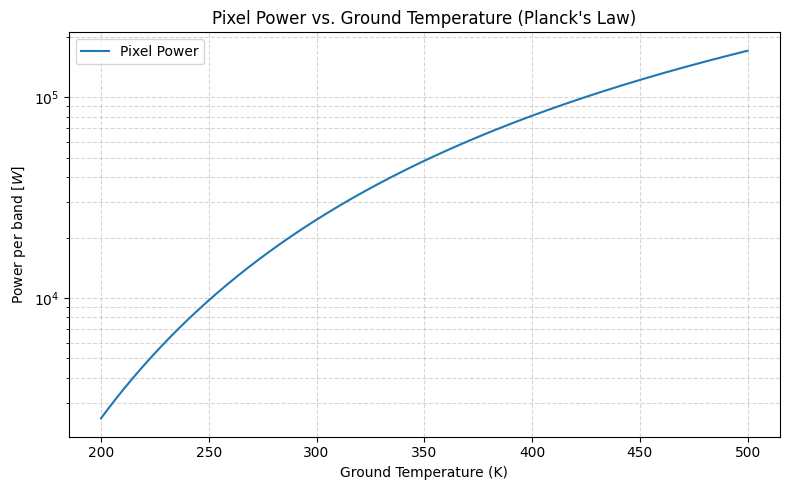

In [8]:
temperatures = np.linspace(200, 500, 500);

total_powers = []
for T in temperatures:
    _, total_power = generic_band_power(band_edges, tau_atm, T, fixed_factors, other_factors, False, n_samples);
    total_powers.append(total_power);

plt.figure(figsize=(8, 5))
plt.plot(temperatures, total_powers, label="Pixel Power")  # x: temperature, y: power

plt.xlabel("Ground Temperature (K)")  # Correct x-axis label
plt.ylabel(r"Power per band $[W]$")
plt.title("Pixel Power vs. Ground Temperature (Planck's Law)")
plt.yscale('log')

plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Todos:
    - Power values way to large
    - Maybe fix Power equation to use detector area?
    - reading of modtran data gives band centers, but are used as band edges